# 01. EDA и подготовка временных рядов

Задачи:

- загрузить временные ряды;
- привести данные к `pandas.Series`;
- проверить пропуски, типы данных и временные метки;
- провести EDA;
- проверить стационарность ADF / KPSS;
- сохранить результаты анализа в папку `reports/`.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose

# Запускать ноутбук лучше из корня проекта.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebook':
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

from src.ts_pipeline import load_series, infer_frequency, infer_season_length

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
REPORT_DIR = PROJECT_ROOT / 'reports'
FIG_DIR = REPORT_DIR / 'figures'
REPORT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 100)

In [2]:
raw_files = sorted(RAW_DIR.glob('*.csv'))
raw_files

[PosixPath('/home/osboxes/Desktop/project_neto_time_completion/data/raw/daily-total-female-births-in-cal.csv'),
 PosixPath('/home/osboxes/Desktop/project_neto_time_completion/data/raw/international-airline-passengers.csv'),
 PosixPath('/home/osboxes/Desktop/project_neto_time_completion/data/raw/mean-monthly-air-temperature-deg.csv'),
 PosixPath('/home/osboxes/Desktop/project_neto_time_completion/data/raw/monthly-boston-armed-robberies-j.csv'),
 PosixPath('/home/osboxes/Desktop/project_neto_time_completion/data/raw/monthly-sales-of-company-x-jan-6.csv'),
 PosixPath('/home/osboxes/Desktop/project_neto_time_completion/data/raw/weekly-closings-of-the-dowjones-.csv')]

In [3]:
series_dict = {}
summary_rows = []

for file in raw_files:
    s = load_series(file, name=file.stem)
    series_dict[file.name] = s
    summary_rows.append({
        'file': file.name,
        'n_obs': len(s),
        'start': s.index.min(),
        'end': s.index.max(),
        'freq': infer_frequency(s),
        'season_length': infer_season_length(s),
        'missing_values': int(s.isna().sum()),
        'min': float(s.min()),
        'max': float(s.max()),
        'mean': float(s.mean()),
        'std': float(s.std()),
    })

eda_summary = pd.DataFrame(summary_rows)
eda_summary.to_csv(REPORT_DIR / 'eda_summary.csv', index=False)
eda_summary

/home/osboxes/Desktop/project_neto_time_completion/src/ts_pipeline.py:73: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed.loc[regular] = pd.to_datetime(text.loc[regular], errors="coerce")
/home/osboxes/Desktop/project_neto_time_completion/src/ts_pipeline.py:73: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed.loc[regular] = pd.to_datetime(text.loc[regular], errors="coerce")
/home/osboxes/Desktop/project_neto_time_completion/src/ts_pipeline.py:73: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed.loc[regular] = pd.to_datetime(text.loc[regular], errors="coerce")
/

,file,n_obs,start,end,freq,season_length,missing_values,min,max,mean,std
0,daily-total-female-births-in-cal.csv,365,1959-01-01,1959-12-31,D,7,0,23.00,73.00,41.980822,7.348257
1,international-airline-passengers.csv,144,1949-01-01,1960-12-01,MS,12,0,104.00,622.00,280.298611,119.966317
2,mean-monthly-air-temperature-deg.csv,240,1920-01-01,1939-12-01,MS,12,0,31.30,66.50,49.041250,8.569705
3,monthly-boston-armed-robberies-j.csv,118,1966-01-01,1975-10-01,MS,12,0,29.00,500.00,196.288136,128.043602
4,monthly-sales-of-company-x-jan-6.csv,77,1965-01-01,1971-05-01,MS,12,0,36.00,895.00,298.402597,198.430570
5,weekly-closings-of-the-dowjones-.csv,162,1971-07-05,1974-08-05,W-MON,52,0,752.58,1047.49,907.484753,60.599919


## Визуальный анализ рядов

На графиках проверяем наличие тренда, сезонности, выбросов и изменения дисперсии.

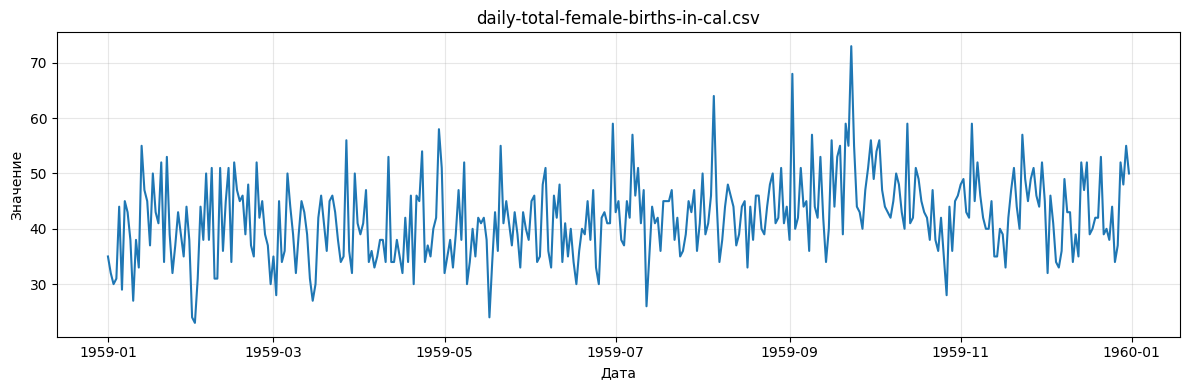

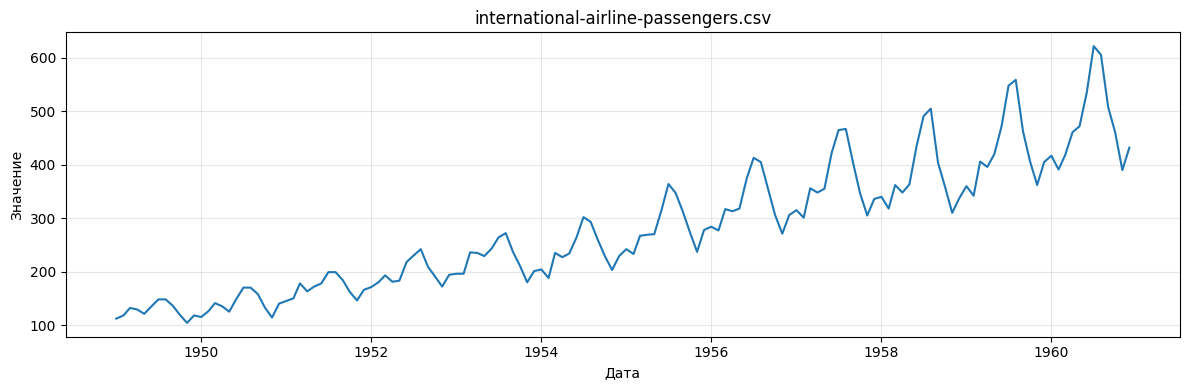

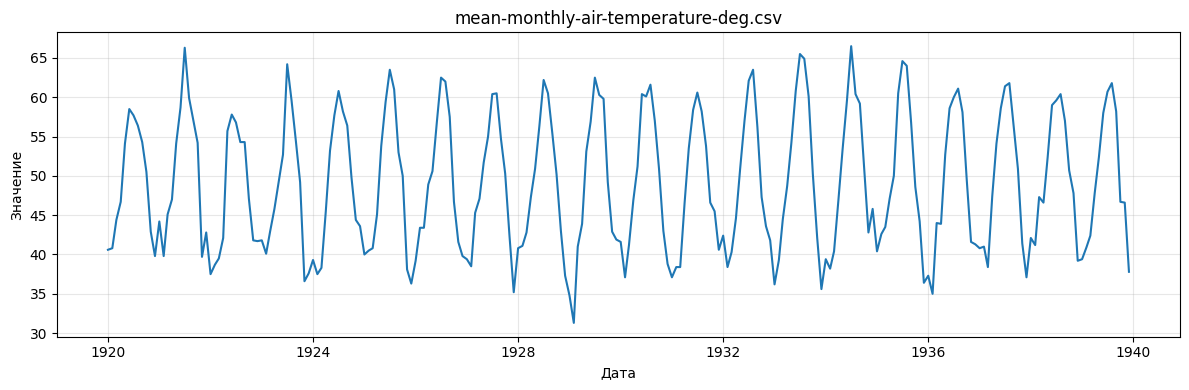

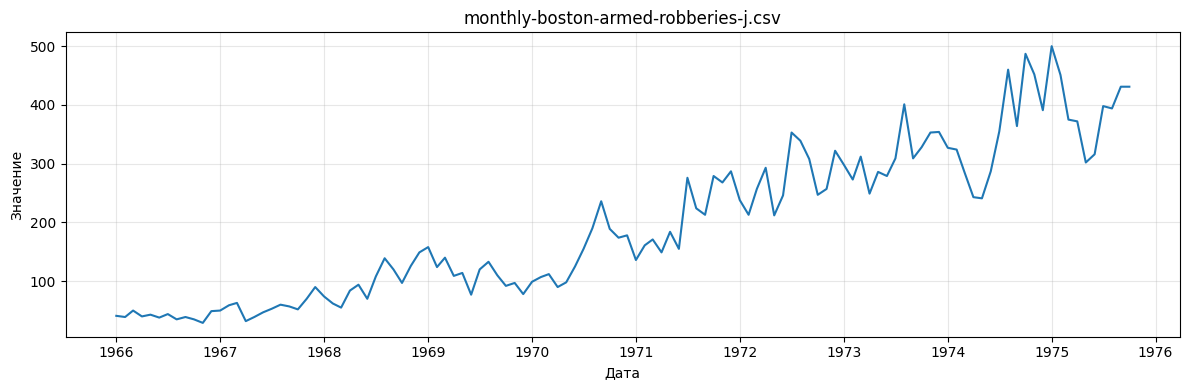

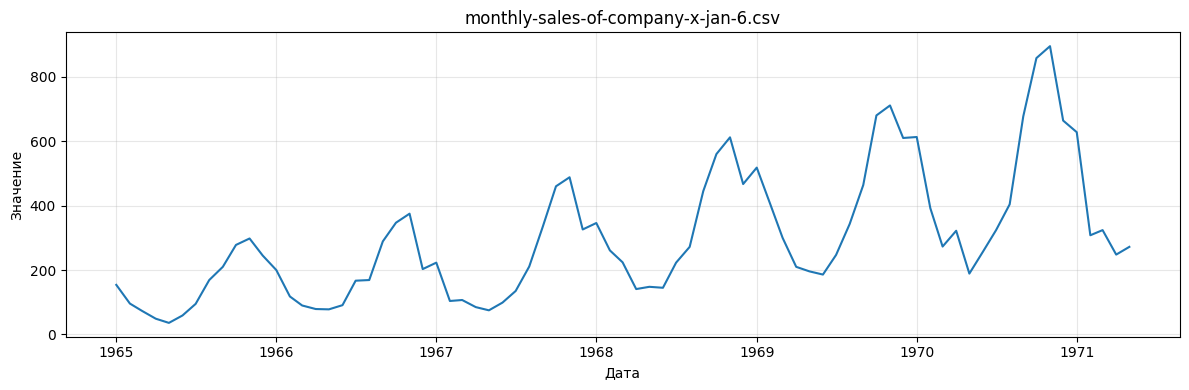

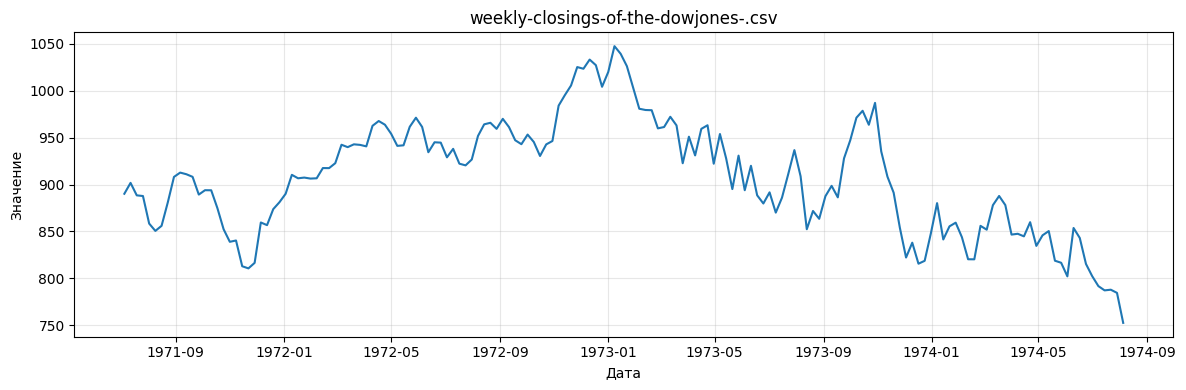

In [4]:
for name, s in series_dict.items():
    plt.figure(figsize=(12, 4))
    plt.plot(s.index, s.values)
    plt.title(name)
    plt.xlabel('Дата')
    plt.ylabel('Значение')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"eda_{Path(name).stem}.png", dpi=150)
    plt.show()

- `daily-total-female-births-in-cal.csv`: ряд это дневные колебания вокруг относительно стабильного уровня, без выраженного долгосрочного тренда. Есть отдельные всплески, но явной устойчивой сезонности на глаз не видно.
- `international-airline-passengers.csv`: ряд имеет сильный восходящий тренд и выраженную годовую сезонность. Амплитуда сезонных колебаний растет вместе с уровнем ряда, поэтому структура ближе к мультипликативной сезонности.
- `mean-monthly-air-temperature-deg.csv`: хорошо выражена повторяющаяся годовая сезонность, при этом долгосрочный тренд практически отсутствует. Это визуально самый регулярный сезонный ряд из представленных.
- `monthly-boston-armed-robberies-j.csv`: наблюдается устойчивый восходящий тренд и рост разброса значений во времени. Исходный ряд нельзя считать стационарным без преобразований.
- `monthly-sales-of-company-x-jan-6.csv`: видны тренд, сильная сезонность и увеличение амплитуды пиков. Для такого ряда желательно учитывать сезонный период 12 и возможную мультипликативную структуру.
- `weekly-closings-of-the-dowjones-.csv`: ряд меняет направление движения во времени: сначала рост, затем снижение. Явной сезонности не видно, но есть трендовые участки и смена режима, поэтому стационарность исходного ряда сомнительна.

## Проверка стационарности

Используются два теста:

- ADF: нулевая гипотеза - ряд имеет единичный корень;
- KPSS: нулевая гипотеза - ряд стационарен.

Практический критерий:

- ADF p-value < 0.05;
- KPSS p-value > 0.05.

In [5]:
def stationarity_tests(series):
    x = series.dropna()
    result = {}
    try:
        adf = adfuller(x, autolag='AIC')
        result['adf_stat'] = adf[0]
        result['adf_pvalue'] = adf[1]
    except Exception as e:
        result['adf_stat'] = np.nan
        result['adf_pvalue'] = np.nan
        result['adf_error'] = str(e)

    try:
        kpss_result = kpss(x, regression='c', nlags='auto')
        result['kpss_stat'] = kpss_result[0]
        result['kpss_pvalue'] = kpss_result[1]
    except Exception as e:
        result['kpss_stat'] = np.nan
        result['kpss_pvalue'] = np.nan
        result['kpss_error'] = str(e)

    result['is_stationary_rule'] = (
        result.get('adf_pvalue', np.nan) < 0.05 and
        result.get('kpss_pvalue', np.nan) > 0.05
    )
    return result

stationarity_rows = []
for name, s in series_dict.items():
    row = {'file': name}
    row.update(stationarity_tests(s))
    stationarity_rows.append(row)

stationarity_summary = pd.DataFrame(stationarity_rows)
stationarity_summary.to_csv(REPORT_DIR / 'stationarity_summary.csv', index=False)
stationarity_summary

/tmp/ipykernel_5268/3679788860.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(x, regression='c', nlags='auto')
/tmp/ipykernel_5268/3679788860.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(x, regression='c', nlags='auto')
/tmp/ipykernel_5268/3679788860.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(x, regression='c', nlags='auto')
/tmp/ipykernel_5268/3679788860.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kp

,file,adf_stat,adf_pvalue,kpss_stat,kpss_pvalue,is_stationary_rule
0,daily-total-female-births-in-cal.csv,-4.808291,0.000052,1.612966,0.010000,False
1,international-airline-passengers.csv,0.815369,0.991880,1.651312,0.010000,False
2,mean-monthly-air-temperature-deg.csv,-3.255492,0.016989,0.043860,0.100000,True
3,monthly-boston-armed-robberies-j.csv,1.001102,0.994278,1.711870,0.010000,False
4,monthly-sales-of-company-x-jan-6.csv,0.654715,0.988889,0.852438,0.010000,False
5,weekly-closings-of-the-dowjones-.csv,-1.314625,0.622455,0.583430,0.024143,False


## Детальный EDA выбранного ряда

Для итогового исследования выбран `international-airline-passengers.csv`. В нем есть тренд и сезонность, поэтому на нем удобно сравнивать статистические, ML и DL-модели.

In [6]:
TARGET_FILE = 'international-airline-passengers.csv'
target = series_dict[TARGET_FILE]
period = infer_season_length(target)

print('Частота:', infer_frequency(target))
print('Сезонный период:', period)
print('Количество наблюдений:', len(target))

target.head(), target.tail()

Частота: MS
Сезонный период: 12
Количество наблюдений: 144


(ds
 1949-01-01    112.0
 1949-02-01    118.0
 1949-03-01    132.0
 1949-04-01    129.0
 1949-05-01    121.0
 Name: international-airline-passengers, dtype: float64,
 ds
 1960-08-01    606.0
 1960-09-01    508.0
 1960-10-01    461.0
 1960-11-01    390.0
 1960-12-01    432.0
 Name: international-airline-passengers, dtype: float64)

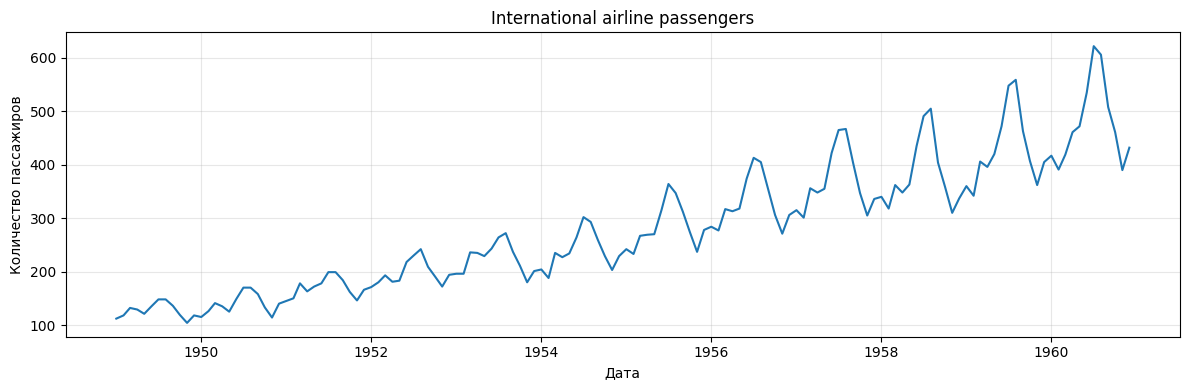

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(target.index, target.values)
plt.title('International airline passengers')
plt.xlabel('Дата')
plt.ylabel('Количество пассажиров')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'target_airline_passengers.png', dpi=150)
plt.show()

Ряд пассажиропотока имеет устойчивый восходящий тренд: к концу периода значения существенно выше, чем в начале. Также видны регулярные сезонные пики и спады внутри каждого года. Амплитуда сезонности увеличивается по мере роста уровня ряда, поэтому перед моделированием стоит использовать сезонные признаки, дифференцирование, логарифмирование или модели, которые умеют учитывать тренд и сезонность.

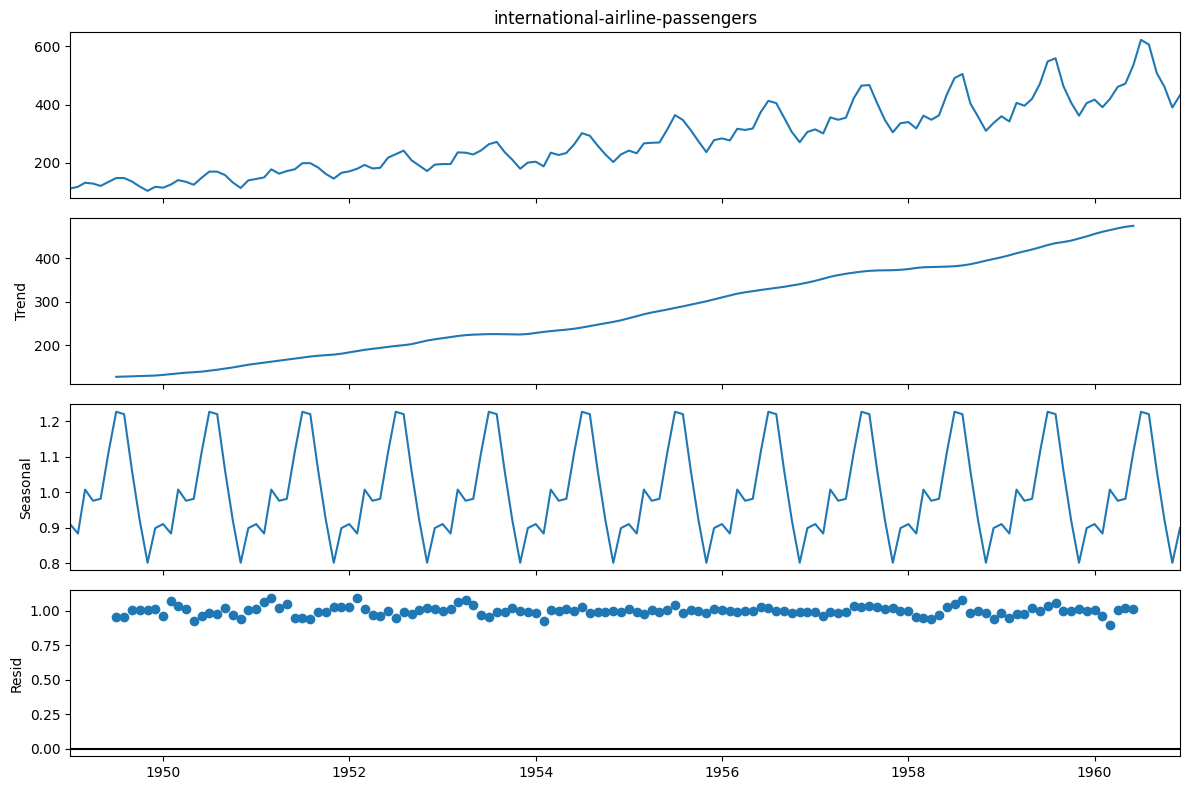

In [8]:
# Декомпозиция: тренд, сезонность, остатки.
decomp = seasonal_decompose(target, model='multiplicative', period=period)
fig = decomp.plot()
fig.set_size_inches(12, 8)
fig.tight_layout()
fig.savefig(FIG_DIR / 'target_decomposition.png', dpi=150)
plt.show()

тренд плавно растет, сезонная компонента повторяется с периодом 12 месяцев, а остатки после выделения тренда и сезонности колеблются около стабильного уровня. Это означает, что основная структура ряда объясняется трендом и годовой сезонностью, а для прогноза нужно использовать методы, способные учитывать обе компоненты.

## Вывод по EDA

На этапе EDA загружены и проверены 6 временных рядов. Все ряды успешно приведены к формату `pandas.Series`, временные метки распознаны, пропуски отсутствуют. Данные различаются по частоте: есть дневной ряд, месячные ряды и недельный ряд Dow Jones. Для каждого ряда определена предполагаемая сезонность: 7 для дневного ряда, 12 для месячных рядов и 52 для недельного ряда.

Визуальный анализ показал, что ряды имеют разную структуру. `mean-monthly-air-temperature-deg.csv` демонстрирует устойчивую годовую сезонность без явного долгосрочного тренда. `international-airline-passengers.csv` и `monthly-sales-of-company-x-jan-6.csv` имеют тренд и растущую сезонную амплитуду. `monthly-boston-armed-robberies-j.csv` показывает сильный восходящий тренд и изменение разброса. `weekly-closings-of-the-dowjones-.csv` имеет смену направления движения и не выглядит стационарным. `daily-total-female-births-in-cal.csv` колеблется вокруг относительно стабильного уровня, но результаты тестов требуют осторожной интерпретации.

Основной ряд `international-airline-passengers.csv` содержит 144 месячных наблюдения за 1949-1960 годы. В нем нет пропусков, есть выраженный восходящий тренд и годовая сезонность. Тесты ADF и KPSS не подтверждают стационарность исходного ряда: ADF p-value = 0.9919, KPSS p-value = 0.0100. Поэтому для прогноза нужны модели, которые учитывают тренд и сезонность, либо признаки/преобразования, которые передают эту структуру.

Для дальнейшего исследования выбран ряд `international-airline-passengers.csv`, потому что он содержит 144 месячных наблюдения, имеет частоту `MS`, сезонный период 12 и хорошо выраженные компоненты тренда и сезонности. Мультипликативная декомпозиция подтвердила, что структура ряда в основном объясняется плавно растущим трендом и регулярной годовой сезонностью. Это делает ряд удобным для дальнейшего сравнения статистических, ML- и DL-подходов к прогнозированию временных рядов.